In [39]:
!pip install boto3

In [30]:
import boto3
import zipfile
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import numpy as np
import tensorflow as tf
import json
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as pp
import mlflow

In [54]:
path = "AAI_540_Group_7/Testing_Data.zip"
extract = "AAI_540_Group_7/Testing_Data/"

os.makedirs(extract, exist_ok=True)

with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall(extract)

print("Extraction complete!")

Extraction complete!


In [2]:
s3 = boto3.client("s3") #Created session

In [3]:
bucket_name = "maize-v1" #Created bucket

s3.create_bucket(
    Bucket=bucket_name
)

{'ResponseMetadata': {'RequestId': '7CRAZCV2DVHR52F2',
  'HostId': 'PDXScHf5EOoyl4kNMEE8EhIb1+c/ysO90TVkU5tkRJYwPsxfYsy3Vdg8LA2TO5WmxZGrG8OBAqT2NZ/Z+UroCIZZpiI7QndM',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'PDXScHf5EOoyl4kNMEE8EhIb1+c/ysO90TVkU5tkRJYwPsxfYsy3Vdg8LA2TO5WmxZGrG8OBAqT2NZ/Z+UroCIZZpiI7QndM',
   'x-amz-request-id': '7CRAZCV2DVHR52F2',
   'date': 'Sun, 14 Jun 2026 12:57:45 GMT',
   'location': '/maize-v1',
   'x-amz-bucket-arn': 'arn:aws:s3:::maize-v1',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'Location': '/maize-v1',
 'BucketArn': 'arn:aws:s3:::maize-v1'}

In [51]:
bucket = "maize-v1" #Uploading our model to S3 bucket
try:
    s3.upload_file(
        "AAI_540_Group_7/Model_V1.0.keras",
        bucket,
        "models/Model_V1.0.keras"
    )
except Exception as e:
    print(f"Error : {e}")
else:
    print("Uploaded")

Uploaded


In [4]:
model = load_model("AAI_540_Group_7/Model_V1.0.keras")

In [10]:
IMG_SIZE = 256
BATCH_SIZE = 32
PATH = "AAI_540_Group_7/Testing_Data/Testing_Data"

prod_ds = tf.keras.utils.image_dataset_from_directory(
    PATH,
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)
print(prod_ds.class_names) #Same as our development data

Found 1592 files belonging to 4 classes.


['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


In [15]:
# Confusion Matrix
y_test = []
y_prob = []
y_pred = []

for images, labels in prod_ds:
    pred = model.predict(images)
    y_test.extend(labels.numpy())
    y_prob.extend(pred)
    y_pred.extend(np.argmax(pred, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step


2026-06-14 13:04:45.821738: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
#Lets see how our developed model performs on real world testing data
report = classification_report(y_test, y_pred)

print(report)#Model is performing really well on our prod data, therefore, re-fitting is not required

              precision    recall  f1-score   support

           0       0.98      0.86      0.92       342
           1       1.00      1.00      1.00       538
           2       0.85      0.98      0.91       282
           3       1.00      1.00      1.00       430

    accuracy                           0.96      1592
   macro avg       0.96      0.96      0.96      1592
weighted avg       0.97      0.96      0.96      1592



In [19]:
#Lets save our metrics in a json
metrics = {
    "accuracy": float(
        accuracy_score(y_test, y_pred)
    ),
    "precision": float(
        precision_score(y_test, y_pred,
                        average="weighted")
    ),
    "recall": float(
        recall_score(y_test, y_pred,
                     average="weighted")
    ),
    "f1": float(
        f1_score(y_test, y_pred,
                 average="weighted")
    )
}

with open("Metrics_V1.0.json","w") as f:
    json.dump(metrics,f,indent=4)

In [22]:
#Keeping tabs on our model performance on available production data
s3.upload_file(
    "Metrics_V1.0.json",
    bucket_name,
    "metrics/Metrics_V1.0.json"
)

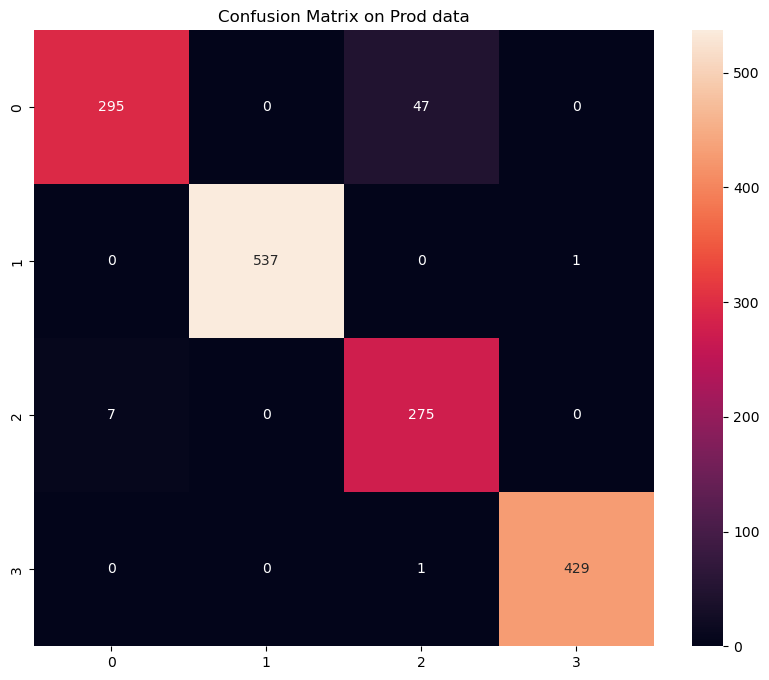

In [28]:
cm = confusion_matrix(y_test, y_pred)

pp.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

pp.title("Confusion Matrix on Prod data")

pp.savefig("confusion_matrix_V1.0.png")

In [29]:
s3.upload_file(
    "confusion_matrix_V1.0.png",
    bucket_name,
    "reports/confusion_matrix_V1.0.png"
)
#Storing performance on prod data in the form of confusion matrix image also

In [32]:
mlflow.set_experiment(
    "maize-disease-classification-model"
)

with mlflow.start_run():

    mlflow.log_param(
        "model",
        "CNN"
    )

    mlflow.log_metric(
        "accuracy",
        metrics["accuracy"]
    )

    mlflow.log_metric(
        "f1",
        metrics["f1"]
    )

    mlflow.log_artifact(
        "confusion_matrix_V1.0.png"
    )

    mlflow.log_artifact(
        "AAI_540_Group_7/Model_V1.0.keras"
    )

In [38]:
experiment = mlflow.get_experiment_by_name(
    "maize-disease-classification-model"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

runs[[
    "run_id",
    "metrics.accuracy",
    "metrics.f1",
    "params.model"
]]

,run_id,metrics.accuracy,metrics.f1,params.model
0,908662ec0aa34eed8dc42783b2c53369,NaN,NaN,None
1,2b5acafec9244163a217408129257095,0.964824,0.964941,CNN
2,e625f52826414d28ab5a15be2b6a7cd4,0.964824,0.964941,CNN
